In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_score,silhouette_samples

In [0]:
spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

In [0]:
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width",180)

In [0]:
CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes", #usage intensity
    "sessions_per_day",        #frequency
    "days_active_last_30",     #consistencyspotify_user_behavior = spark.table(
    "avg_session_minutes",     #depth
    "skip_rate",               #content friction
    "liked_songs_pct",         #positive engagement
    "ads_skipped_pct",         #monetization friction
]

In [0]:
base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()
K=4
X12 = base[CLUSTER_FEATURES_V1].copy()
Power= PowerTransformer(
    method="yeo-johnson",
    standardize=True,
)
X12_Power = Power.fit_transform(X12)
X12 = pd.DataFrame(X12_Power, columns = CLUSTER_FEATURES_V1, index = base.index)

gmm12= GaussianMixture (
    n_components= K,
    covariance_type = "spherical",
    random_state=42,
    n_init=5,
    max_iter = 200
)

In [0]:
labels12 = gmm12.fit_predict(X12)
log_likelihood12 = gmm12.score(X12) * len(X12)
sill_avg_12 = silhouette_score(X12, labels12)
base_iter12 = base.copy()
base_iter12["cluster"] = labels12
print(f"\nIteration 10 results | k={K}")
print("Log Likelihood:", round(log_likelihood12,3))
print("Silhouette :", round(sill_avg_12,3))


Iteration 10 results | k=4
Log Likelihood: -1016991.738
Silhouette : 0.16


In [0]:
sizes12 = base_iter12["cluster"].value_counts().sort_index()
means12 = (
    base_iter12.groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

In [0]:
profile12 = means12.copy()
profile12.insert(0,"cluster_size",sizes12)
print("\n Cluster Profile (means, original scale) -- Iteration 12 (Gaussian Mixture Labels):")
display(profile12)


 Cluster Profile (means, original scale) -- Iteration 12 (Gaussian Mixture Labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
46952,16.65762799909718,1.087,20.29157243678624,16.086041567181475,0.391,0.25589197276048703,0.4904487886959136
20790,51.41395414737884,1.0,18.269011535967344,51.41395414737884,0.266,0.21625214045050797,0.6910054555115059
17010,90.22763310266866,2.714,22.07025444987739,33.65299074532328,0.287,0.30859240407820443,0.5835829481948266
23248,49.78399867637043,1.0,24.887757484028757,49.78399867637043,0.275,0.3935593736360633,0.4908236932396404


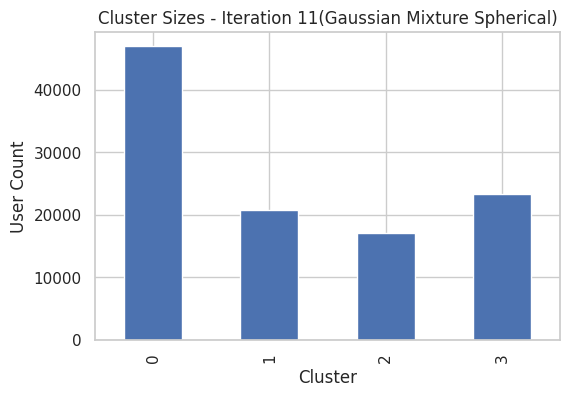

In [0]:
plt.figure(figsize=(6,4))
base_iter12["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration 11(Gaussian Mixture Spherical)")
plt.xlabel("Cluster")
plt.ylabel("User Count")
plt.show()

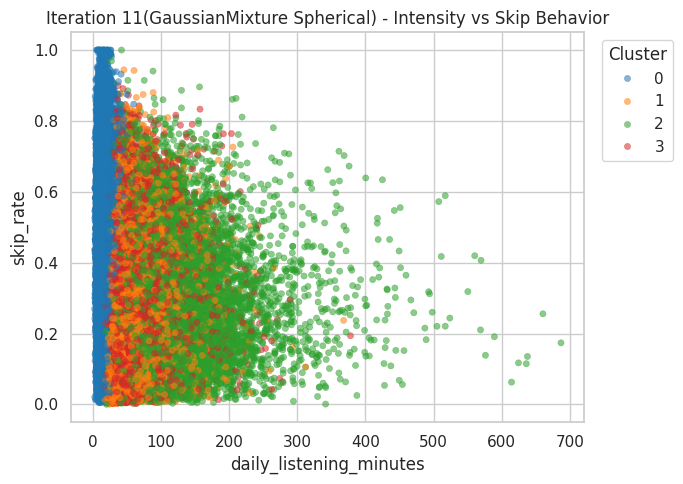

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data = base_iter12,
    x = "daily_listening_minutes",
    y = "skip_rate",
    hue = "cluster",
    palette = "tab10",
    s= 20,
    alpha = 0.55,
    edgecolor = None
    )
plt.title("Iteration 11(GaussianMixture Spherical) - Intensity vs Skip Behavior")
plt.legend(title="Cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()


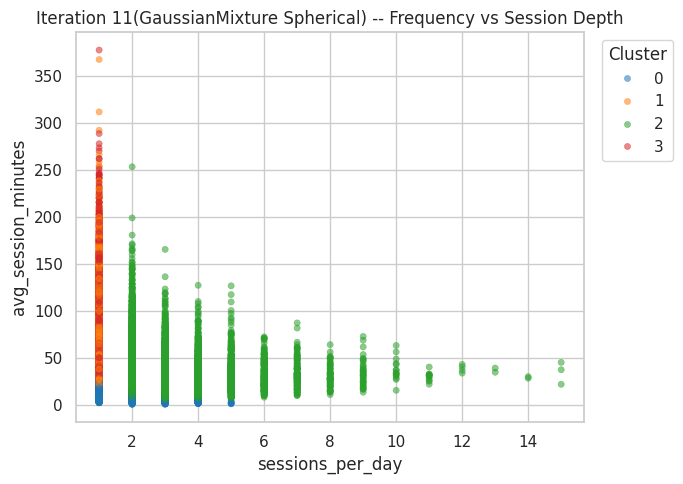

In [0]:
#frequency vs Session depth
plt.figure(figsize=(7,5))
sns.scatterplot(
    data= base_iter12,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration 11(GaussianMixture Spherical) -- Frequency vs Session Depth")
plt.legend(title="Cluster",bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

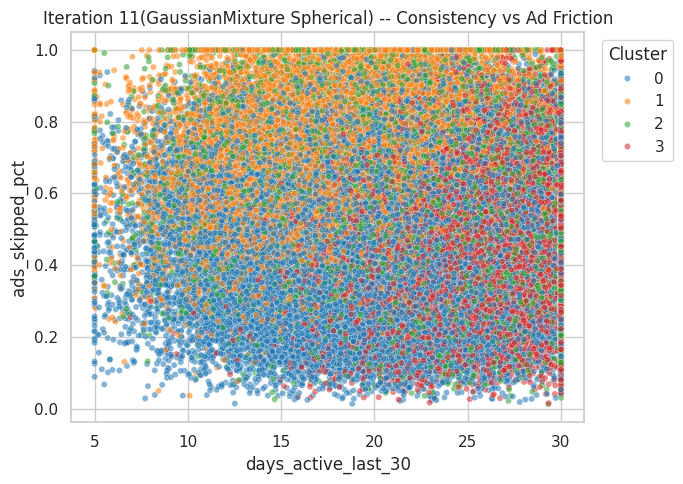

In [0]:
#Consisitency vs Ad Friction
plt.figure(figsize=(7,5))
sns.scatterplot(
    data= base_iter12,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
)
plt.title("Iteration 11(GaussianMixture Spherical) -- Consistency vs Ad Friction")
plt.legend(title="Cluster",bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

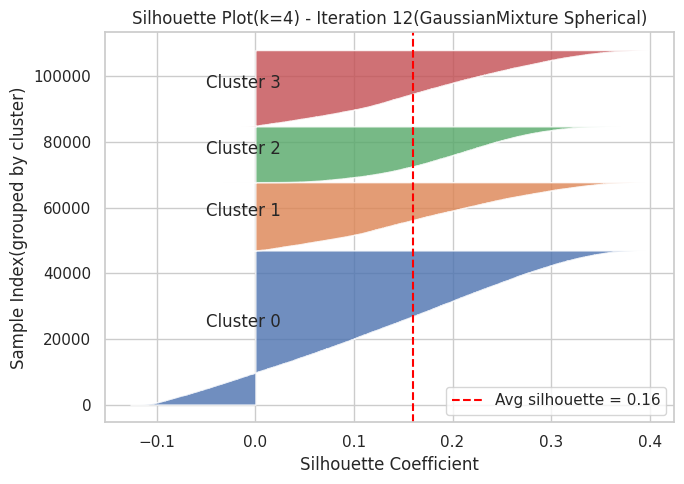

Iteration 12 Avg Silhouette 0.16


In [0]:
# Silhouette Plot
sil_value_12 = silhouette_samples(X12, labels12)
sill_avg_12 = silhouette_score(X12, labels12)
plt.figure(figsize=(7,5))
y_lower = 0

vals0 = sil_value_12[labels12 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals0,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size0,
    "Cluster 0 "
)
y_lower = y_upper 


vals1 = sil_value_12[labels12 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size1,
    "Cluster 1 "
)
y_lower = y_upper 


vals2 = sil_value_12[labels12 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals2,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size2,
    "Cluster 2 "
)
y_lower = y_upper 


vals3 = sil_value_12[labels12 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals3,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size3,
    "Cluster 3 "
)
y_lower = y_upper 


plt.axvline(
    x=sill_avg_12,
    color="red",
    linestyle="--",
    label = f"Avg silhouette = {sill_avg_12:.2f}"
)
plt.title("Silhouette Plot(k=4) - Iteration 12(GaussianMixture Spherical)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

print("Iteration 12 Avg Silhouette", round(sill_avg_12,3))